# 02 Simple Exponential Smoothing

Simple exponential smoothing is used when the series has no clear trend or seasonal factor, but its mean level may slowly change over time.

The level update is

$$l_t = \alpha y_t + (1-\alpha)l_{t-1}, \quad 0 \le \alpha \le 1.$$

The one-period-ahead forecast made after observing time `t` is

$$\hat y_{t+1|t} = l_t.$$

A larger `alpha` reacts more quickly to recent observations. A smaller `alpha` produces a smoother level estimate.

## Why the Weights Are Exponential

Repeatedly substituting the update equation into itself gives the level as a weighted average of the current observation, older observations, and the initial level:

$$l_t = \alpha y_t + \alpha(1-\alpha)y_{t-1} + \alpha(1-\alpha)^2y_{t-2} + \cdots + (1-\alpha)^t l_0.$$

The weights get smaller geometrically as observations get older. This is why the method is called exponential smoothing.

The same update can also be written in error-correction form:

$$l_t = l_{t-1} + \alpha(y_t-l_{t-1}).$$

The term $y_t-l_{t-1}$ is the one-step forecast error. A larger `alpha` corrects more of the latest error immediately; a smaller `alpha` corrects it more slowly.


In [1]:
from lite_setup import ensure_packages
await ensure_packages()

Running outside JupyterLite; assuming packages are already installed.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from checks import check_between, check_close, check_columns
from smoothing_utils import (
    accuracy_measures, initial_level_mean, initial_line,
    simple_es, optimize_simple_es,
    holt_trend, optimize_holt, holt_forecast_table,
    holt_winters, optimize_holt_winters, holt_winters_forecast,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 4)
DATA_DIR = Path('data')

In [3]:
cod = pd.read_csv(DATA_DIR / 'cod_catch.csv')
y = cod['CodCatch'].to_numpy()

l0 = initial_level_mean(y, n=12)
print(f'Initial level from the first 12 observations: {l0:.4f}')
print(check_close(l0, 360.6666667, tol=1e-4, label='initial level'))

Initial level from the first 12 observations: 360.6667
OK: initial level is close to 360.6666667.


In [4]:
fit_alpha_10 = simple_es(y, alpha=0.10, l0=l0)
fit_alpha_10.head(8)

,Time,y,yhat_one_step,level,error,squared_error
0,1,362.0,360.6667,360.8000,1.3333,1.7778
1,2,381.0,360.8000,362.8200,20.2000,408.0400
2,3,317.0,362.8200,358.2380,-45.8200,2099.4724
3,4,297.0,358.2380,352.1142,-61.2380,3750.0926
4,5,399.0,352.1142,356.8028,46.8858,2198.2782
5,6,402.0,356.8028,361.3225,45.1972,2042.7887
6,7,375.0,361.3225,362.6903,13.6775,187.0740
7,8,349.0,362.6903,361.3212,-13.6903,187.4230


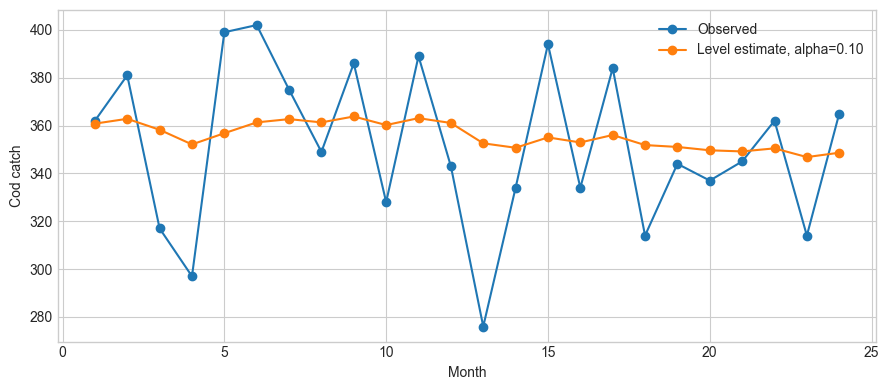

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cod['Time'], y, marker='o', label='Observed')
ax.plot(cod['Time'], fit_alpha_10['level'], marker='o', label='Level estimate, alpha=0.10')
ax.set_xlabel('Month')
ax.set_ylabel('Cod catch')
ax.legend()
plt.tight_layout()

## Optimizing the Smoothing Constant

For a chosen initial level, the fitted one-step forecasts depend on `alpha`. We choose `alpha` by minimizing the sum of squared one-step forecast errors:

$$SSE = \sum_{t=1}^T (y_t - \hat y_{t|t-1})^2.$$

In [6]:
alpha_opt, fit_opt, metrics_opt = optimize_simple_es(y, l0=l0)
lT = fit_opt['level'].iloc[-1]
print(f'Optimal alpha: {alpha_opt:.4f}')
print(f'Final level l_T: {lT:.4f}')
print(check_close(alpha_opt, 0.034, tol=0.005, label='optimized alpha'))
print(check_close(lT, 354.5438, tol=0.1, label='final level l_T'))
pd.Series(metrics_opt).to_frame('value')

Optimal alpha: 0.0344
Final level l_T: 354.5438
OK: optimized alpha is close to 0.034.
OK: final level l_T is close to 354.5438.


,value
SSE,28089.1409
MAD,28.6767
MSE,1170.3809
MAPE,8.5372


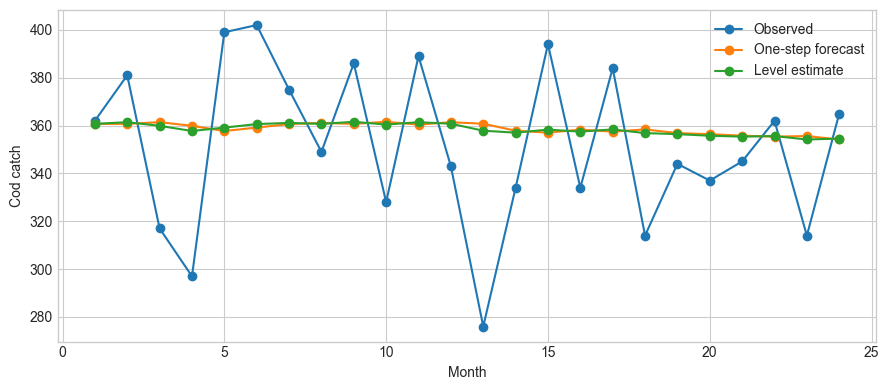

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cod['Time'], y, marker='o', label='Observed')
ax.plot(cod['Time'], fit_opt['yhat_one_step'], marker='o', label='One-step forecast')
ax.plot(cod['Time'], fit_opt['level'], marker='o', label='Level estimate')
ax.set_xlabel('Month')
ax.set_ylabel('Cod catch')
ax.legend()
plt.tight_layout()

## Multi-Step Point Forecasts

For simple exponential smoothing, all future point forecasts from time `T` are equal to the final level estimate:

$$\hat y_{T+\tau|T} = l_T, \quad \tau = 1,2,\ldots$$

The model does not include trend or seasonality, so the point forecast is flat. Prediction intervals should widen as the horizon grows, but the exact formula depends on the statistical error model used by the software.

In [8]:
lT = fit_opt['level'].iloc[-1]
pd.DataFrame({'tau': range(1, 7), 'forecast': lT})

,tau,forecast
0,1,354.5438
1,2,354.5438
2,3,354.5438
3,4,354.5438
4,5,354.5438
5,6,354.5438
